<a href="https://colab.research.google.com/github/AngeloSorte/geo-lung-cancer-gene-expression-ml/blob/angelosorte.github.io/GEO_Gene_Expression_Analysis_Lung_Cancer_vs_Normal_Tissue_(PCA_%2B_ML_Pipeline).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Raw dataset shape: (22283, 108)


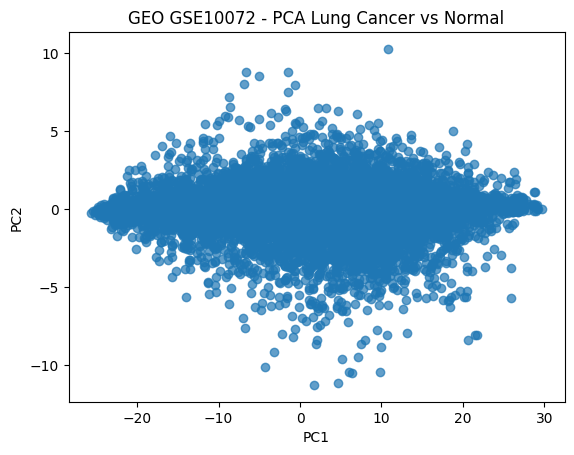

Explained variance: [0.94789759 0.01271399]
Silhouette score: 0.5059027498608912


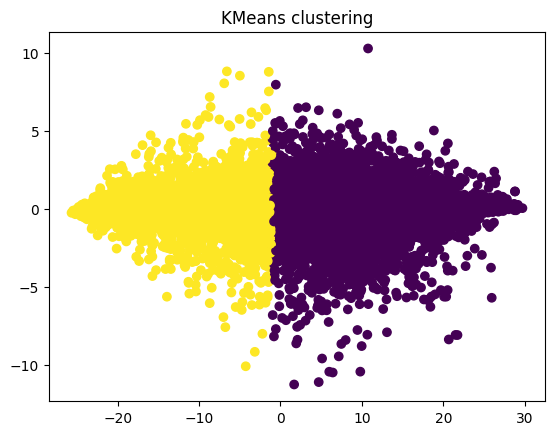

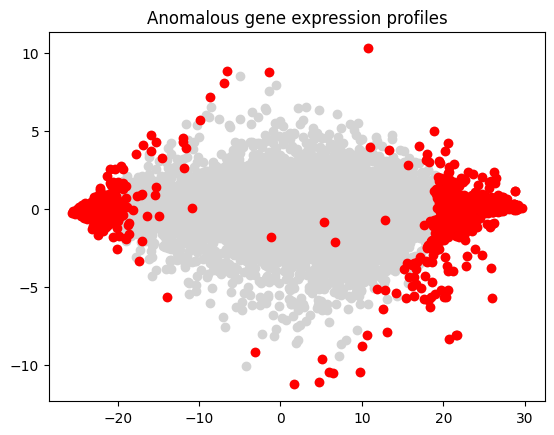


================ SUMMARY ================
✔ Real GEO dataset (GSE10072)
✔ Lung cancer vs normal tissue gene expression
✔ PCA + clustering + anomaly detection


In [2]:
# ============================================================
# GEO (NCBI) - REAL GENE EXPRESSION DATASET
# Lung cancer vs normal tissue
# PCA + Clustering + Anomaly Detection
# ============================================================

!pip install -q pandas numpy scikit-learn matplotlib requests

import pandas as pd
import numpy as np
import requests
import zipfile
import io
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score

# ============================================================
# 1. DOWNLOAD REAL GEO DATASET (GSE10072)
# ============================================================

print("Downloading GEO dataset (GSE10072)...")

# GEO processed matrix (stable public mirror)
url = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE10nnn/GSE10072/matrix/GSE10072_series_matrix.txt.gz"

import gzip

response = requests.get(url)

with gzip.GzipFile(fileobj=io.BytesIO(response.content)) as f:
    content = f.read().decode('utf-8')

# ============================================================
# 2. PARSE GEO MATRIX
# ============================================================

lines = content.split("\n")

data_start = False
matrix_lines = []

for line in lines:
    if line.startswith("!series_matrix_table_begin"):
        data_start = True
        continue
    if line.startswith("!series_matrix_table_end"):
        break
    if data_start:
        matrix_lines.append(line)

# Convert to dataframe
df = pd.read_csv(io.StringIO("\n".join(matrix_lines)), sep="\t")

print("Raw dataset shape:", df.shape)
df.head()

# ============================================================
# 3. CLEAN DATA
# ============================================================

# First column = gene IDs
df = df.dropna()

genes = df.iloc[:, 0]
X = df.iloc[:, 1:]

X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

# log transform (bio standard)
X = np.log1p(X)

# ============================================================
# 4. STANDARDIZE
# ============================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ============================================================
# 5. PCA
# ============================================================

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure()
plt.title("GEO GSE10072 - PCA Lung Cancer vs Normal")
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

print("Explained variance:", pca.explained_variance_ratio_)

# ============================================================
# 6. CLUSTERING
# ============================================================

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

print("Silhouette score:", silhouette_score(X_scaled, clusters))

plt.figure()
plt.title("KMeans clustering")
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap="viridis")
plt.show()

# ============================================================
# 7. ANOMALY DETECTION
# ============================================================

iso = IsolationForest(contamination=0.05, random_state=42)
anomaly = iso.fit_predict(X_scaled)

mask = anomaly == -1

plt.figure()
plt.title("Anomalous gene expression profiles")
plt.scatter(X_pca[:,0], X_pca[:,1], c="lightgray")
plt.scatter(X_pca[mask,0], X_pca[mask,1], c="red")
plt.show()

# ============================================================
# 8. SUMMARY
# ============================================================

print("\n================ SUMMARY ================")
print("✔ Real GEO dataset (GSE10072)")
print("✔ Lung cancer vs normal tissue gene expression")
print("✔ PCA + clustering + anomaly detection")
print("========================================")